In [2]:
import numpy as np
import matplotlib.pyplot as plt

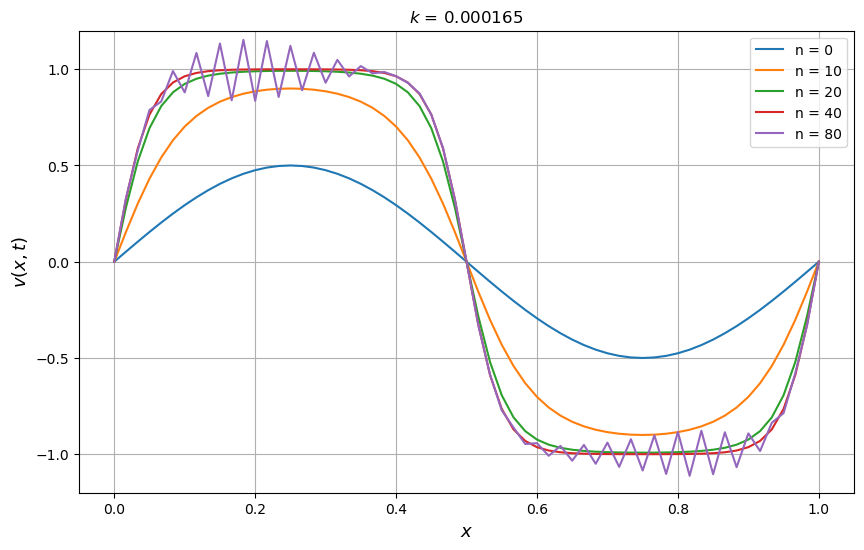

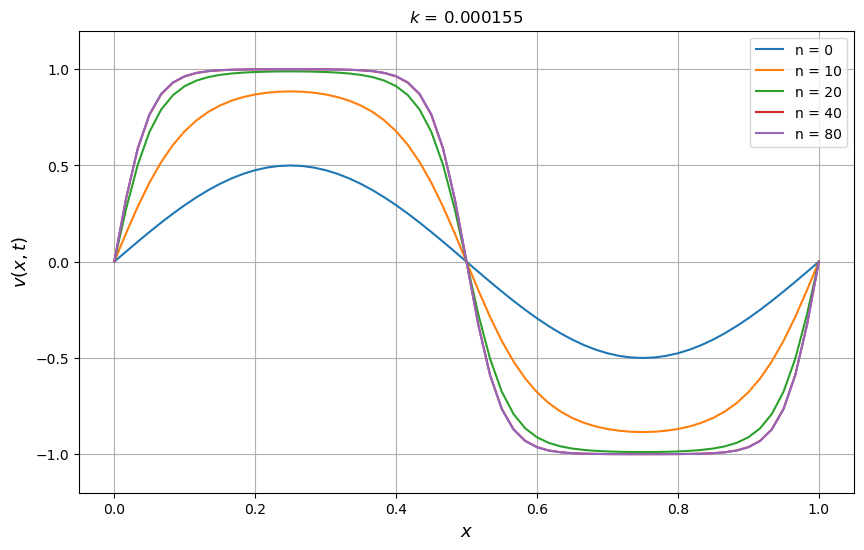

In [26]:
def allen_cahn_forward_euler(k, h=1/60, gamma=800, timesteps=[0, 10, 20, 40, 80]):
  # Define the grid on the interval [0, 1] with spacing h
  N = int(1/h)
  x = np.linspace(0, 1, N+1)

  # We're told to use Dirichlet boundary conditions, so u_0 = u_N = 0 and we should just use interior points
  x_int = x[1:-1]

  # Define the initial condition we're told to use
  u = 0.5 * np.sin(2*np.pi*x_int)

  # Go ahead and define the figure
  plt.figure(figsize=(10, 6))

  # Define the maximum timestep to go to and just capture snippets at each time. But, overall, we need to go up to 80
  max_step = max(timesteps)
  plot_steps = set(timesteps)

  # Calculate up to the maximum timestep
  for n in range(max_step+1):
    if n in plot_steps:
      # If the timestep is in our list of snippet timesteps ([0, 10, 20, 40, 80]), then plot
      u_full = np.concatenate([[0], u, [0]])  # This should take care of the Dirichlet boundary conditions on the edges
      plt.plot(x, u_full, label=f'n = {n}')

    # Always check the if statement first, then move on to updating using Forward Euler
    # Note that u itself is an array from [u_1, ..., u_N-1]
    u_minus = np.concatenate([[0], u[:-1]]) # u_minus here is the array from [u_0, ..., u_N-2], with 0 on the LHS
    u_plus = np.concatenate([u[1:], [0]])   # u_right here is the array from [u_2, ..., u_N], with 0 on the RHS

    laplacian = (u_plus - 2*u + u_minus) / h**2
    nonlinear = gamma * (u - u**3)
    u = u + k * (laplacian + nonlinear)

  # Plot all of the curves together
  plt.xlabel(r'$x$', fontsize=13)
  plt.ylabel(r'$v(x, t)$', fontsize=13)
  plt.title(rf'$k$ = {k}')
  plt.legend()
  plt.grid(True)
  plt.ylim(-1.2, 1.2)
  plt.show()

# Plot for case (i): k = 0.000165
allen_cahn_forward_euler(k=0.000165)

# Plot for case (ii): k = 0.000155
allen_cahn_forward_euler(k=0.000155)

In [52]:
def heat_2d_forward_euler(h=0.1, k=0.0025, t_final=2.0):
  # Define the grid we're going to use. Note we're going from [0, 1] in both dimensions, so 
  # N = 1 divided by the grid spacing, h
  N = int(1/h)
  x = np.linspace(0, 1, N+1)
  y = np.linspace(0, 1, N+1)

  # Our initial condition is v(x, y, 0) = 0, so initialize array this way
  u = np.zeros((N+1, N+1))

  # Apply the Dirichlet boundary conditions:
  # Left edge: v(0, y, t) = 0
  u[0,:] = 0
  # Right edge: v(1, y, t) = 0
  u[N,:] = 0
  # Top edge: v(x, 1, t) = 1
  u[:,N] = 1
  # Corner points (this isn't used in the scheme, we're just setting to 1 for plotting)
  u[0,N] = 1
  u[N,N] = 1

  # Find the total number of timesteps to go through
  n_steps = int(t_final / k)

  # Loop through timesteps until we reach the max
  for n in range(n_steps):
    # Only update the interior points and keep the boundaries the same to satisfy conditions (only update j=1:N-1 and i=1:N-1)
    u_interior = u[1:-1, 1:-1]

    # Calculate D+D- in the x-direction: (u[i+1,j] - 2u[i,j] + u[i-1,j]) / h^2
    laplacian_x = (u[2:, 1:-1] - 2*u_interior + u[:-2, 1:-1]) / h**2

    # Calculate D+D- in y direction: (u[i,j+1] - 2u[i,j] + u[i,j-1]) / h^2
    laplacian_y = (u[1:-1, 2:] - 2*u_interior + u[1:-1, :-2]) / h**2

    # Forward Euler update (only the interior points)
    u[1:-1, 1:-1] = u_interior + k * (laplacian_x + laplacian_y)

  # Meshgrid for plotting
  X, Y = np.meshgrid(x, y)
    
  # Contour plot
  plt.figure(figsize=(6, 5))
  plt.contour(X, Y, u.T, levels=20)
  plt.colorbar(label='Temperature')
  plt.xlabel(r'$x$', fontsize=12)
  plt.ylabel(r'$y$', fontsize=12)
  plt.show()
    
  # Surface plot
  fig = plt.figure(figsize=(10, 6))
  ax = fig.add_subplot(111, projection='3d')
  ax.plot_surface(X, Y, u.T, cmap='viridis')
  ax.set_xlabel(r'$x$', fontsize=12, labelpad = 10)
  ax.set_ylabel(r'$y$', fontsize=12, labelpad = 10)
  ax.set_zlabel(r'Temperature', fontsize=12, labelpad = 10)
  ax.set_box_aspect(None, zoom=0.80)
  plt.show()

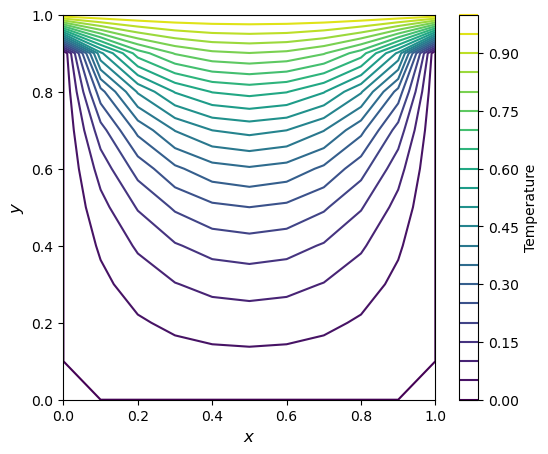

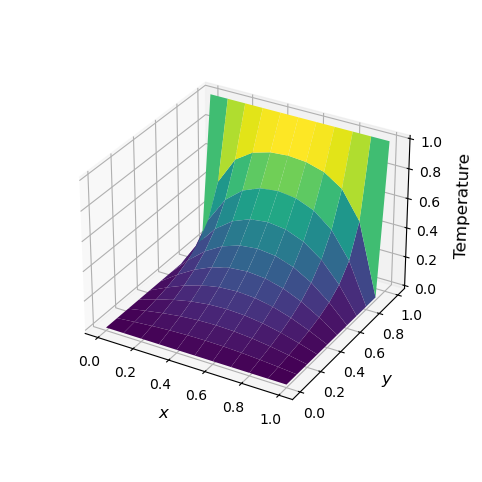

In [53]:
heat_2d_forward_euler()